# 03 图像聚类（CLIP + FAISS）

**目标**：用 CLIP 提取图像特征，再对特征做 K-Means 聚类（如 10 簇），观察 CIFAR10 的 10 个真实类别在各簇中的分布，理解 CLIP 特征是否具有语义聚集性。

**步骤**：安装依赖与 FAISS → 加载 CLIP 与 CIFAR10 → 提取测试集图像特征并写入 FAISS 索引 → K-Means 聚类 → 可视化各类别在簇中的分布。

## 1. 安装所需依赖包

## 2. 安装 FAISS（支持 GPU 或 CPU）
仅 CPU 时安装 faiss-cpu。
使用 GPU 时安装 faiss-gpu。
根据硬件取消下方对应行的注释并运行。

In [1]:
#pip install faiss-gpu
#pip install faiss-cpu

## 3. 加载主干项目模型（best.pt）
使用本仓库训练得到的模型（256 维投影），与 01、02 一致。

In [2]:
# 导入依赖并挂载主干项目
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
from transformers import CLIPTokenizer
from datasets import load_dataset, load_from_disk
import faiss
import time

ROOT = Path("/root/CLIP_26_ylslch")
if not (ROOT / "config.py").exists():
    ROOT = Path.cwd().resolve()
    while ROOT != ROOT.parent and not (ROOT / "config.py").exists():
        ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import config as CFG
from dataset import get_transforms
from models import CLIPModel as ProjectCLIPModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transforms = get_transforms(mode="valid")
model = ProjectCLIPModel().to(device)
model.load_state_dict(torch.load(ROOT / "best.pt", map_location=device))
model.eval()

def pil_to_tensor(pil_img):
    img_np = np.array(pil_img)
    if len(img_np.shape) == 2:
        img_np = np.stack([img_np] * 3, axis=-1)
    out = transforms(image=img_np)["image"]
    return torch.tensor(out).permute(2, 0, 1).float().unsqueeze(0)


libgomp: Invalid value for environment variable OMP_NUM_THREADS
/root/miniconda3/envs/ylslch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

libgomp: Invalid value for environment variable OMP_NUM_THREADS

libgomp: Invalid value for environment variable OMP_NUM_THREADS
Loading weights: 100%|██████████| 198/198 [00:00<00:00, 803.33it/s, Materializing param=layernorm.weight]                                 
ViTModel LOAD REPORT from: /root/CLIP_26_ylslch/checkpoint/google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you ex

## 3. 加载 CIFAR10 数据集
该数据集包含 10 个预定义类别。

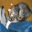

In [3]:
# 加载 CIFAR10 数据集（使用本地 dataset/cifar10，避免在线下载）
dataset = load_from_disk(str(ROOT / "dataset" / "cifar10"))

# 默认仅使用测试集前 1000 张
subset_size = min(1000, len(dataset['test']))
test_dataset = dataset['test'].select(range(subset_size))

# 展示一张图像
display(test_dataset[0]['img'])

## 4. 提取测试集图像（默认 1000 张）特征并存入 FAISS 索引
为创建聚类，需提取数据集中所有图像的特征。将特征存入 FAISS 索引。主干模型特征维度为 256，因此创建参数 256 的索引。定义两个函数：
* **extract_features_clip**：输入一张图像，返回其特征向量。
* **add_vector_to_index**：将特征加入 FAISS 索引；加入前先转为 numpy float32 并做 L2 归一化。

最后遍历数据集以提取并存储特征。


In [4]:
# 将向量加入 FAISS 索引
def add_vector_to_index(embedding, index):
    # 将嵌入转为 numpy
    vector = embedding.detach().cpu().numpy()
    # 转为 float32 numpy
    vector = np.float32(vector)
    # 归一化向量
    faiss.normalize_L2(vector)
    # 加入索引
    index.add(vector)

# 提取给定图像的特征
def extract_features_clip(image):
    with torch.no_grad():
        x = pil_to_tensor(image).to(device)
        feat = model.image_projection(model.image_encoder(x))
        return F.normalize(feat, p=2, dim=-1)

# 创建 FAISS 索引（256 维）
index = faiss.IndexFlatL2(256)

# 遍历数据集（默认 1000 张），提取所有图像特征并写入索引
for image in test_dataset:
    clip_features = extract_features_clip(image['img'])
    add_vector_to_index(clip_features,index)
    
# 将索引写入本地，便于后续复用
faiss.write_index(index,"clip.index")

## 5. 创建 10 个聚类

首先获取所有向量。然后定义聚类参数：
* **ncentroids**：聚类个数（簇数）。
* **niter**：K-Means 迭代次数。
* **d**：向量维度（此处为 256）。

最后对向量应用 K-Means 聚类。


In [5]:
# 从索引中取出所有向量
vectors = index.reconstruct_n(0, len(test_dataset))

# 定义聚类数与参数
x= vectors
ncentroids = 10
niter = 50
verbose = True
d = x.shape[1]

t0=time.time()
# 执行 K-Means 聚类
kmeans = faiss.Kmeans(d, ncentroids, niter=niter, verbose=verbose)
kmeans.train(x)
print('Clustering done in ', time.time()-t0)

# 聚类分配结果：[向量数组, 每个向量所属簇 id 数组]
cluster_assignments = kmeans.assign(vectors)
print(cluster_assignments)
# 仅打印簇 id
clusters_ind = cluster_assignments[1]
print(clusters_ind)

Clustering 1000 points in 256D to 10 clusters, redo 1 times, 50 iterations
  Preprocessing in 0.00 s
  Iteration 49 (0.17 s, search 0.11 s): objective=496.674 imbalance=1.008 nsplit=0       
Clustering done in  0.17148089408874512
(array([0.6255946 , 0.29616535, 0.40309823, 0.57037544, 0.34394026,
       0.65740097, 0.3566295 , 0.5871229 , 0.39328372, 0.27953982,
       0.62036586, 0.2187928 , 0.54477865, 0.49488544, 0.18899739,
       0.53391254, 0.5773864 , 0.41539395, 0.42498136, 0.28352845,
       0.6286031 , 0.56879914, 0.5711772 , 0.45474076, 0.75976914,
       0.86564523, 0.6177581 , 0.4945922 , 0.18429899, 0.31903887,
       0.7722571 , 0.58925647, 0.6393025 , 0.78168344, 0.27164447,
       0.7238748 , 0.3790747 , 0.5397843 , 0.4371655 , 0.42265671,
       0.5171483 , 0.5941266 , 0.6082344 , 0.69621676, 0.4284613 ,
       0.13639283, 0.64920276, 0.5544771 , 0.43212414, 0.45344067,
       0.26703513, 0.3098359 , 0.47250652, 0.7017331 , 0.43101585,
       0.59522843, 0.43793213, 

## 6. 创建矩阵存储各聚类中的向量分布并可视化
创建一个 10×10 的空矩阵，用于存储各簇中各类别（标签）的分布。

In [6]:
distribution = np.zeros((10, 10), dtype=int)
print(distribution)

[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]


遍历聚类分配数组填充矩阵。x 轴为聚类 ID，y 轴为图像标签（0-9）。矩阵解读方式如下：
* distribution[簇id][标签id]：该簇中该标签的图像数量。例如 distribution[0][0] 表示簇 0 中标签为 0 的图像数，distribution[0][1] 表示簇 0 中标签为 1 的图像数。


In [7]:
for vector_index,cluster_nb in enumerate(clusters_ind):
    label = test_dataset[vector_index]['label']
    distribution[cluster_nb][label]+=1
 
print(distribution)

[[  0   0  93   0   0   0   0   0   0   0]
 [  0  83   0   0   0   0   0   0   1   4]
 [  3   0   0   0   0   0   0   1 101   1]
 [  0   0   0   0   5   0   0  99   0   0]
 [  1   2   2  71   0   2   7   1   1   1]
 [  1   4   0   1   0   0   0   0   0 101]
 [ 98   0   2   0   0   0   1   0   3   2]
 [  0   0   1  28   1  83   2   1   0   0]
 [  0   0   0   1   0   0 101   0   0   0]
 [  0   0   2   2  84   1   1   0   0   0]]


按簇汇总图像数量，查看每个簇分配到的图像数。

In [8]:
row_sums = np.sum(distribution, axis=1)
print("每个聚类的图像数量：")
print(row_sums)

每个聚类的图像数量：
[ 93  88 106 104  88 107 106 116 102  90]


绘制每个簇内各类别（标签）的分布图。

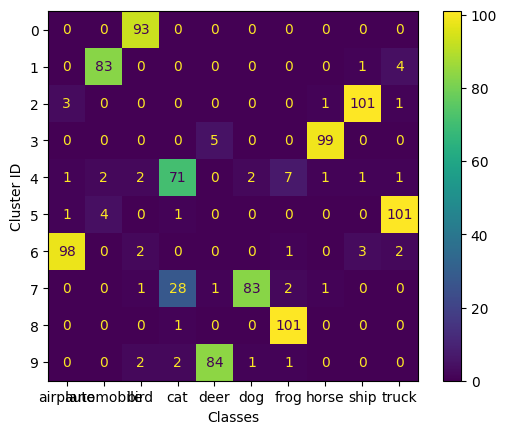

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=distribution)
disp.plot()
plt.ylabel('Cluster ID')
plt.xlabel('Classes')
labels = dataset["train"].features["label"].names
x = range(len(labels))
ticks = labels
plt.xticks(x, ticks)
plt.show()